In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns

matplotlib.rcParams["font.family"] = "Malgun Gothic"
matplotlib.rcParams["axes.unicode_minus"] = False

df = pd.read_csv("../data/raw/bank.csv")
print(df.shape)
df.head()

(11162, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [2]:
print(df.dtypes)
print("\n결측치:\n", df.isnull().sum())
print("\n기술통계:\n")
df.describe()

age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
deposit      object
dtype: object

결측치:
 age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64

기술통계:



,age,balance,day,duration,campaign,pdays,previous
count,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000
mean,41.231948,1528.538524,15.658036,371.993818,2.508421,51.330407,0.832557
std,11.913369,3225.413326,8.420740,347.128386,2.722077,108.758282,2.292007
min,18.000000,-6847.000000,1.000000,2.000000,1.000000,-1.000000,0.000000
25%,32.000000,122.000000,8.000000,138.000000,1.000000,-1.000000,0.000000
50%,39.000000,550.000000,15.000000,255.000000,2.000000,-1.000000,0.000000
75%,49.000000,1708.000000,22.000000,496.000000,3.000000,20.750000,1.000000
max,95.000000,81204.000000,31.000000,3881.000000,63.000000,854.000000,58.000000


#### 클래스 불균형

deposit
no     5873
yes    5289
Name: count, dtype: int64

가입률: 47.4%


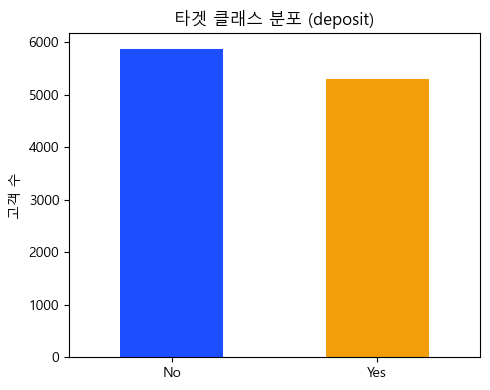

In [3]:
target_counts = df["deposit"].value_counts()
print(target_counts)
print(f"\n가입률: {(df['deposit']=='yes').mean()*100:.1f}%")

fig, ax = plt.subplots(figsize=(5, 4))
target_counts.plot(kind="bar", ax=ax, color=["#1B4FFF", "#F59E0B"])
ax.set_title("타겟 클래스 분포 (deposit)")
ax.set_xlabel("")
ax.set_ylabel("고객 수")
ax.set_xticklabels(["No", "Yes"], rotation=0)
plt.tight_layout()
plt.savefig("../outputs/figures/class_distribution.png", dpi=150)
plt.show()

#### 직군별 반응률

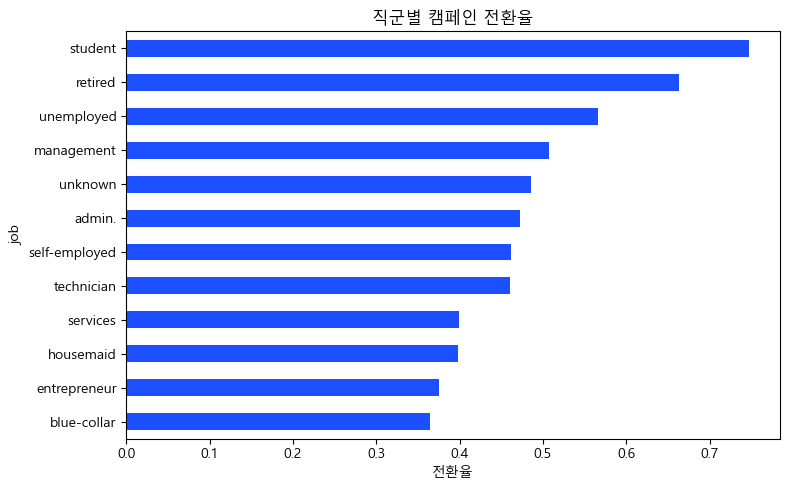

In [4]:
job_cvr = (
    df.groupby("job")["deposit"]
    .apply(lambda x: (x == "yes").mean())
    .sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(8, 5))
job_cvr.plot(kind="barh", ax=ax, color="#1B4FFF")
ax.set_title("직군별 캠페인 전환율")
ax.set_xlabel("전환율")
plt.tight_layout()
plt.savefig("../outputs/figures/job_conversion_rate.png", dpi=150)
plt.show()

#### contact 횟수 vs 전환율

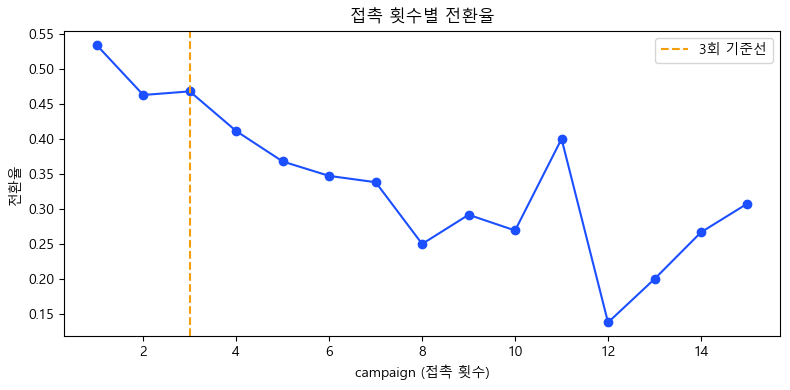

In [5]:
campaign_cvr = (
    df.groupby("campaign")["deposit"]
    .apply(lambda x: (x == "yes").mean())
    .reset_index()
)
campaign_cvr.columns = ["campaign", "cvr"]
campaign_cvr_filtered = campaign_cvr[campaign_cvr["campaign"] <= 15]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(campaign_cvr_filtered["campaign"], campaign_cvr_filtered["cvr"],
        marker="o", color="#1B4FFF")
ax.axvline(3, color="#F59E0B", linestyle="--", label="3회 기준선")
ax.set_title("접촉 횟수별 전환율")
ax.set_xlabel("campaign (접촉 횟수)")
ax.set_ylabel("전환율")
ax.legend()
plt.tight_layout()
plt.savefig("../outputs/figures/campaign_count_cvr.png", dpi=150)
plt.show()

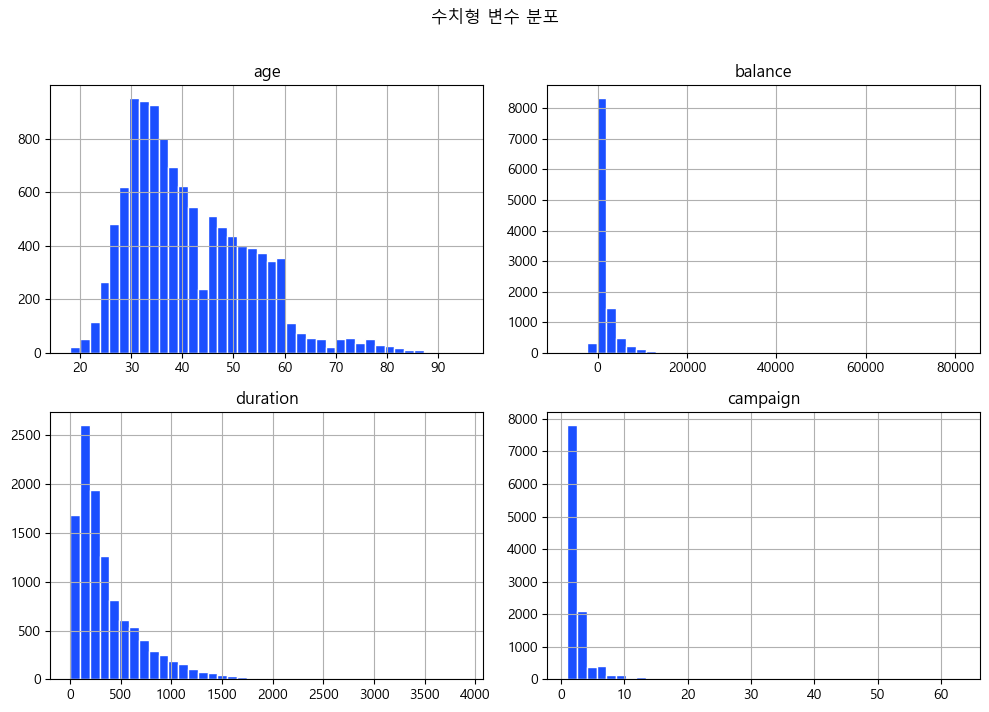

In [6]:
num_cols = ["age", "balance", "duration", "campaign"]

fig, axes = plt.subplots(2, 2, figsize=(10, 7))
for ax, col in zip(axes.flatten(), num_cols):
    df[col].hist(ax=ax, bins=40, color="#1B4FFF", edgecolor="white")
    ax.set_title(col)
plt.suptitle("수치형 변수 분포", y=1.01)
plt.tight_layout()
plt.savefig("../outputs/figures/numeric_distributions.png", dpi=150)
plt.show()

####  poutcome vs 전환율

In [7]:
pout_cvr = (
    df.groupby("poutcome")["deposit"]
    .apply(lambda x: (x == "yes").mean())
    .sort_values(ascending=True)
)
print("이전 캠페인 결과별 전환율:")
print(pout_cvr)

이전 캠페인 결과별 전환율:
poutcome
unknown    0.406678
failure    0.503257
other      0.571695
success    0.913165
Name: deposit, dtype: float64
